<a href="https://colab.research.google.com/github/rishabh-181226/MSBA_PredAnalytics_CaseCompetetion/blob/main/Resume_Ranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.manifold import TSNE

from gensim import corpora
from gensim.models import LdaModel
from sklearn.naive_bayes import MultinomialNB
from scipy.spatial.distance import cosine as cosine_dist
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [ ]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
csv_path = "/content/drive/MyDrive/msba650/Resume.csv"

df = pd.read_csv(csv_path)

df = df[['Resume_str','Category']]


print(f"\nTotal Resumes: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"\nShape: {df.shape}")
df.head()


Total Resumes: 2,484
Columns: 2

Shape: (2484, 2)


,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [ ]:
print(df.columns)

Index(['Resume_str', 'Category'], dtype='object')


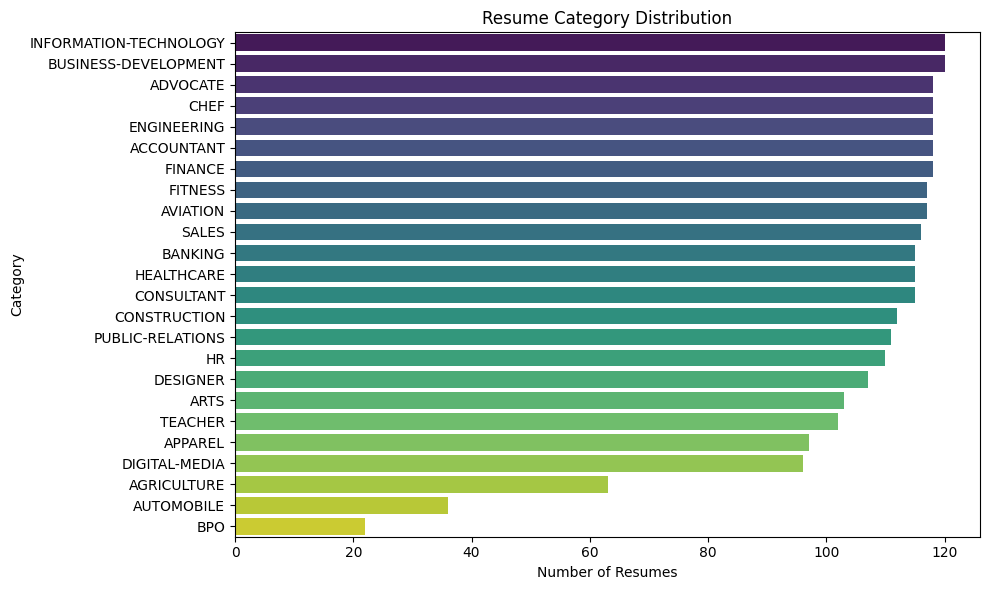

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.countplot(
    y=df["Category"],
    order=df["Category"].value_counts().index,
    palette="viridis"
)

plt.title("Resume Category Distribution")
plt.xlabel("Number of Resumes")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [ ]:
stop_words = set(stopwords.words("english"))

resume_stopwords = {"resume","curriculum","vitae","contact","email","phone",
    "mobile","address","objective","summary","experience",
    "skills","skill","responsibilities","education",
    "university","college","name",
    "state","city","company","work","worked","working",
    "project","projects","team","teams","role","roles",
    "year","years"}
stop_words = stop_words.union(resume_stopwords)

In [ ]:

def clean_text(text):

    if pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]',' ', text)

    tokens = word_tokenize(text)

    tokens = [w for w in tokens if w not in stop_words]

    return " ".join(tokens)

df["clean_resume"] = df["Resume_str"].apply(clean_text)
print(f"Average document length: {df['clean_resume'].str.len().mean():.0f} characters")
print(f"Total text corpus size: {df['clean_resume'].str.len().sum() / 1024 / 1024:.2f} MB")
df.head()

Average document length: 4608 characters
Total text corpus size: 10.91 MB


,Resume_str,Category,clean_resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,hr specialist us hr operations versatile media...
2,HR DIRECTOR Summary Over 2...,HR,hr director recruiting plus human resources ex...
3,HR SPECIALIST Summary Dedica...,HR,hr specialist dedicated driven dynamic custome...
4,HR MANAGER Skill Highlights ...,HR,hr manager highlights hr hr department startup...


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words='english',
    ngram_range=(1,1),
    min_df=5,
    max_df=0.7
)
tfidf_matrix = vectorizer.fit_transform(df['clean_resume'])

X = vectorizer.fit_transform(df["clean_resume"])
y = df["Category"]
print(f"TF-IDF Matrix created")
print(f"Shape: {tfidf_matrix.shape}")
print(f"Using unigrams")

TF-IDF Matrix created
Shape: (2484, 1000)
Using unigrams


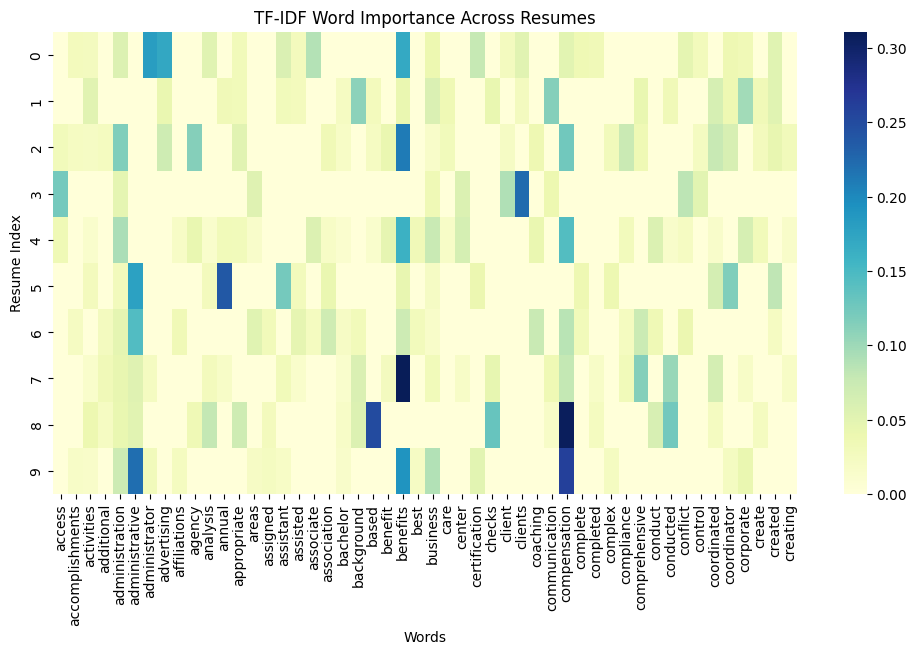

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = vectorizer.get_feature_names_out()

# convert first few resumes into dataframe
tfidf_matrix = pd.DataFrame(
    X[:10].toarray(),
    columns=feature_names)

# keep important words only
tfidf_matrix = tfidf_matrix.loc[:, (tfidf_matrix > 0).sum() > 2]

tfidf_matrix = tfidf_matrix.iloc[:35, :50]

plt.figure(figsize=(12,6))

sns.heatmap(tfidf_matrix, cmap="YlGnBu")

plt.title("TF-IDF Word Importance Across Resumes")

plt.xlabel("Words")
plt.ylabel("Resume Index")

plt.show()

In [ ]:
n_clusters=8
kmeans = KMeans(n_clusters=8, random_state=42)

clusters = kmeans.fit_predict(X)

df["cluster"] = clusters
print(f" K-Means clustering complete")
print(f"Number of clusters: {n_clusters}")
print(f"\nCLUSTER SIZES:")
cluster_sizes = df['cluster'].value_counts().sort_index()
for cluster_id, size in cluster_sizes.items():
    print(f"Cluster {cluster_id}: {size:>3} RESUMES")

 K-Means clustering complete
Number of clusters: 8

CLUSTER SIZES:
Cluster 0: 386 RESUMES
Cluster 1: 543 RESUMES
Cluster 2: 227 RESUMES
Cluster 3: 224 RESUMES
Cluster 4: 171 RESUMES
Cluster 5: 608 RESUMES
Cluster 6: 227 RESUMES
Cluster 7:  98 RESUMES


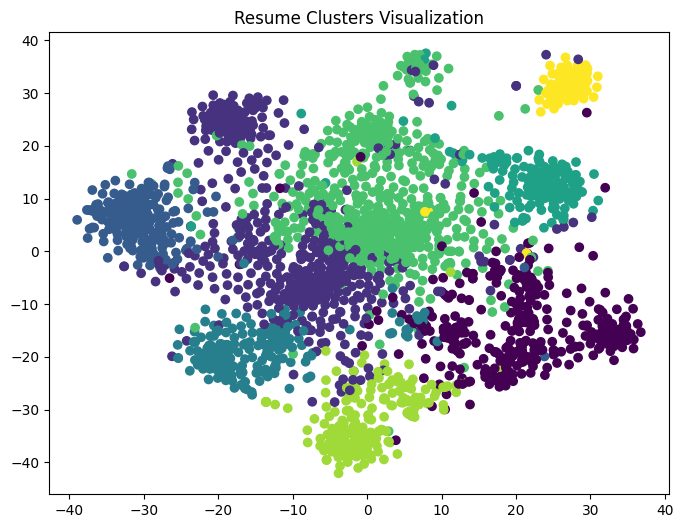

In [ ]:
tsne = TSNE(n_components=2, random_state=42)

X_embedded = tsne.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_embedded[:,0], X_embedded[:,1], c=clusters)
plt.title("Resume Clusters Visualization")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
lda_vectorizer = CountVectorizer(
    max_features=200,
    stop_words='english',
    min_df=3
)
lda_matrix = lda_vectorizer.fit_transform(df['clean_resume'])

n_topics = 8
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=25,
    learning_method='batch'
)

print("Training LDA model...")
doc_topics = lda_model.fit_transform(lda_matrix)
print(f"✅ LDA Model trained with {n_topics} topics")

Training LDA model...
✅ LDA Model trained with 8 topics


In [ ]:
# Display topics
feature_names = lda_vectorizer.get_feature_names_out()

print("\n" + "="*80)
print("LDA DISCOVERED TOPICS (Top 18 words per topic):")
print("="*80)

for topic_idx, topic in enumerate(lda_model.components_):
    top_words_idx = topic.argsort()[-18:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"\nTopic {topic_idx}:")
    print(f"  {' | '.join(top_words)}")


LDA DISCOVERED TOPICS (Top 18 words per topic):

Topic 0:
  students | school | student | program | arts | community | professional | social | activities | development | training | science | research | staff | office | member | special | current

Topic 1:
  design | food | engineering | quality | production | control | equipment | management | safety | cost | product | process | development | new | materials | operations | inventory | maintenance

Topic 2:
  systems | data | management | support | software | information | technology | network | technical | business | microsoft | security | windows | computer | database | using | development | applications

Topic 3:
  financial | accounting | accounts | management | finance | reports | analysis | monthly | reporting | business | general | budget | account | payroll | cash | process | office | prepared

Topic 4:
  customer | service | sales | customers | store | inventory | high | new | needs | cash | maintained | products | daily | inf

In [ ]:
y = df["Category"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LogisticRegression(max_iter=500)

model.fit(X_train,y_train)

pred = model.predict(X_test)

accuracy = accuracy_score(y_test,pred)

print("Model Accuracy:",accuracy)


Model Accuracy: 0.647887323943662


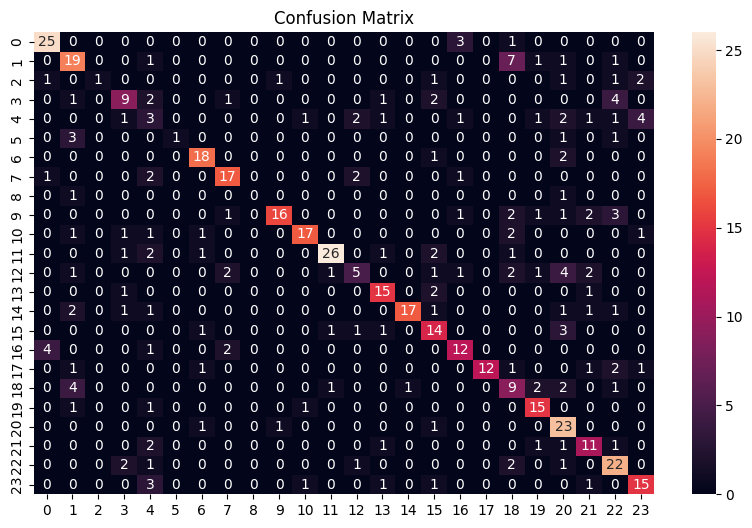

In [ ]:
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(10,6))

sns.heatmap(cm,annot=True,fmt="d")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

MLP Accuracy: 0.5614



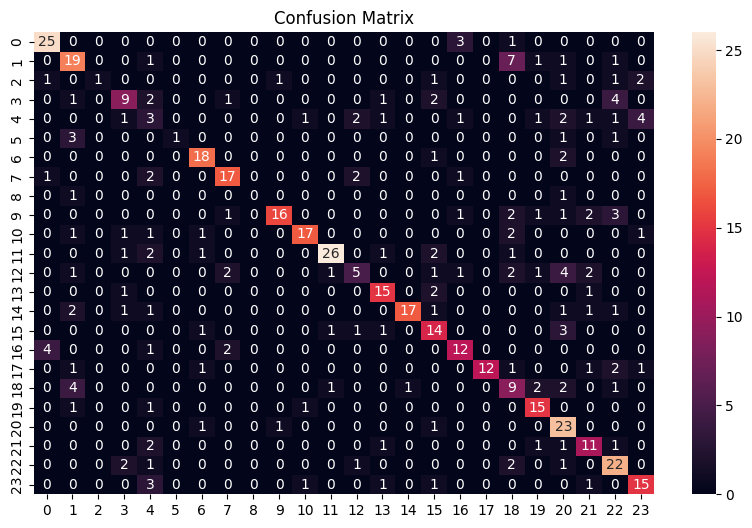

In [ ]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=800,
    learning_rate_init=0.001,
    random_state=42)

mlp_model.fit(X_train, y_train)
mlp_pred = mlp_model.predict(X_test)
mlp_acc = accuracy_score(y_test, mlp_pred)
print("MLP Accuracy:", round(mlp_acc, 4))
print()
cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(10,6))

sns.heatmap(cm,annot=True,fmt="d")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print("Classification report: Logistic Regression")
print(classification_report(y_test, pred))

print("\n" + "="*70 + "\n")

print("Classification report: MLP")
print(classification_report(y_test, mlp_pred))

Classification report: Logistic Regression
                        precision    recall  f1-score   support

            ACCOUNTANT       0.81      0.86      0.83        29
              ADVOCATE       0.56      0.63      0.59        30
           AGRICULTURE       1.00      0.12      0.22         8
               APPAREL       0.56      0.45      0.50        20
                  ARTS       0.15      0.17      0.16        18
            AUTOMOBILE       1.00      0.17      0.29         6
              AVIATION       0.78      0.86      0.82        21
               BANKING       0.74      0.74      0.74        23
                   BPO       0.00      0.00      0.00         2
  BUSINESS-DEVELOPMENT       0.89      0.59      0.71        27
                  CHEF       0.85      0.71      0.77        24
          CONSTRUCTION       0.90      0.76      0.83        34
            CONSULTANT       0.45      0.25      0.32        20
              DESIGNER       0.71      0.79      0.75       

In [ ]:
job_description = """Looking for a Data Analyst with Python, SQL,
data visualization, statistics experience."""

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
job_vector = vectorizer.transform([job_description])

similarity_scores = cosine_similarity(job_vector, X)

top_matches = similarity_scores[0].argsort()[-10:][::-1]

df.iloc[top_matches][["Category","Resume_str"]]


,Category,Resume_str
1218,CONSULTANT,Pavithra Shetty Summary ...
1762,ENGINEERING,ENGINEERING AND QUALITY TECHNICIAN ...
1339,AUTOMOBILE,DATA ANALYST Professional Summa...
926,AGRICULTURE,SOFTWARE DEVELOPER Professi...
1303,DIGITAL-MEDIA,SENIOR DIGITAL MARKETING ANALYST ...
1142,CONSULTANT,CONSULTANT Summary College g...
563,BUSINESS-DEVELOPMENT,BUSINESS DEVELOPMENT ANALYST Su...
1091,SALES,SALES ENGINEER Summary I...
778,HEALTHCARE,SENIOR ANALYST DATA QUALITY & GOVERNA...
315,INFORMATION-TECHNOLOGY,WORKING RF SYSTEMS ENGINEER ...


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Example job description
job_description = """
Looking for a Data Analyst with Python, SQL,
data visualization, statistics, and machine learning experience.
"""

# Convert job description to TF-IDF vector
job_vector = vectorizer.transform([job_description])

# Compute similarity with all resumes
similarity_scores = cosine_similarity(job_vector, X)

# Get top 5 matching resumes
top_indices = similarity_scores[0].argsort()[-5:][::-1]

# Create result table
results = pd.DataFrame({
    "Rank": range(1, len(top_indices)+1),
    "Resume Category": df.iloc[top_indices]["Category"].values,
    "Score": similarity_scores[0][top_indices]
})

# Round scores
results["Score"] = results["Score"].round(2)

print(results)

   Rank Resume Category  Score
0     1      CONSULTANT   0.40
1     2     ENGINEERING   0.35
2     3      AUTOMOBILE   0.28
3     4     AGRICULTURE   0.28
4     5   DIGITAL-MEDIA   0.24


Text(0.5, 1.0, 'Resume Word Cloud')

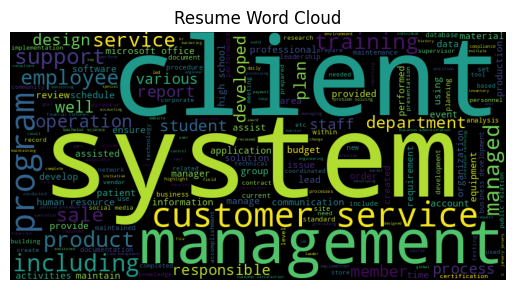

In [ ]:
from wordcloud import WordCloud

text = " ".join(df["clean_resume"])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Resume Word Cloud")

Text(0.5, 1.0, 'Skills by Category')

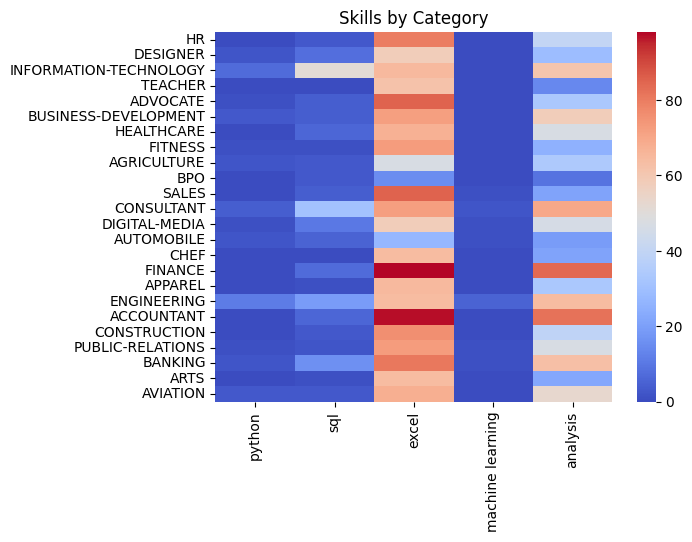

In [ ]:
skills = ["python","sql","excel","machine learning","analysis"]

skill_matrix = pd.DataFrame(
    0,
    index=df["Category"].unique(),
    columns=skills)

for i,row in df.iterrows():

    for skill in skills:

        if skill in row["clean_resume"]:

            skill_matrix.loc[row["Category"],skill]+=1

sns.heatmap(skill_matrix, cmap="coolwarm")

plt.title("Skills by Category")

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.0566353576384595
